# TV Show & Movie Genre Prediction
## Objective
The objective of this project is to develop machine learning models to predict the genre of TV shows and movies using the provided dataset.

This notebook focuses on:
- Data Understanding
- Exploratory Data Analysis (EDA)
- Data Preprocessing


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.metrics import confusion_matrix
%load_ext autoreload
%autoreload 2
warnings.filterwarnings('ignore')

## Data Loading

In this step, the dataset is loaded using a reusable function defined in `data_loader.py`.

Using reusable functions ensures modular and maintainable code.

In [2]:
import sys
import os

sys.path.append(os.path.abspath(r"C:\Users\hemab\Downloads\tv-show-ml-project\src"))

In [4]:
import visualization
import preprocess
import train
import evaluate
import feature_engineering
import data_loader
import data_split

In [5]:

df = data_loader.load_data(r"C:\Users\hemab\Downloads\tv-show-ml-project\data\tv-shows.csv")

df.head()

,id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,platform
0,1,Movie,ChuChuTV Surprise Eggs Learning Videos (English),NaN,NaN,NaN,"October 18, 2019",2019,TV-Y,61 min,Children & Family Movies,From colors and letters to animals of all kind...,Netflix
1,2,Movie,The Journey Is the Destination,Bronwen Hughes,"Ben Schnetzer, Kelly Macdonald, Sam Hazeldine,...",United States,"November 7, 2017",2016,R,123 min,Dramas,Spirited 22-year-old activist and photojournal...,Netflix
2,3,TV Show,Champions,NaN,"Anders Holm, Fortune Feimster, Andy Favreau, J...",United States,"June 19, 2021",2018,TV-14,1 Season,TV Comedies,"Years after getting his girlfriend pregnant, w...",Netflix
3,4,TV Show,The Returned,NaN,"Anne Cosigny, Frédéric Pierrot, Clotilde Hesme...",France,"February 17, 2019",2015,TV-MA,1 Season,"International TV Shows, TV Dramas, TV Horror",On returning home and finding they're believed...,Netflix
4,5,Movie,Super Bheem Bana Vajraveer,Sumit Das,"Sonal Kaushal, Rupa Bhimani, Julie Tejwani, Sa...",India,"June 18, 2019",2018,TV-Y7,63 min,Children & Family Movies,"Hoping to find a magical root, a monster has c...",Netflix


## Exploratory Data Analysis (EDA)

EDA helps in understanding the structure of the dataset, identifying missing values, and analyzing feature distributions.

## Dataset Shape

This step checks the number of rows and columns in the dataset to understand its size.

In [6]:
df.shape

(9338, 13)

In [7]:
rows_before = df.shape[0]

### Column Names

List all columns available in the dataset.

In [8]:
df.columns

Index(['id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description',
       'platform'],
      dtype='object')

## Data Types and Missing Values

This step checks column data types and identifies missing values in each column.

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9338 entries, 0 to 9337
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            9338 non-null   int64 
 1   type          9338 non-null   object
 2   title         9338 non-null   object
 3   director      6483 non-null   object
 4   cast          8400 non-null   object
 5   country       8376 non-null   object
 6   date_added    9325 non-null   object
 7   release_year  9338 non-null   int64 
 8   rating        9331 non-null   object
 9   duration      9335 non-null   object
 10  listed_in     9338 non-null   object
 11  description   9338 non-null   object
 12  platform      9338 non-null   object
dtypes: int64(2), object(11)
memory usage: 948.5+ KB


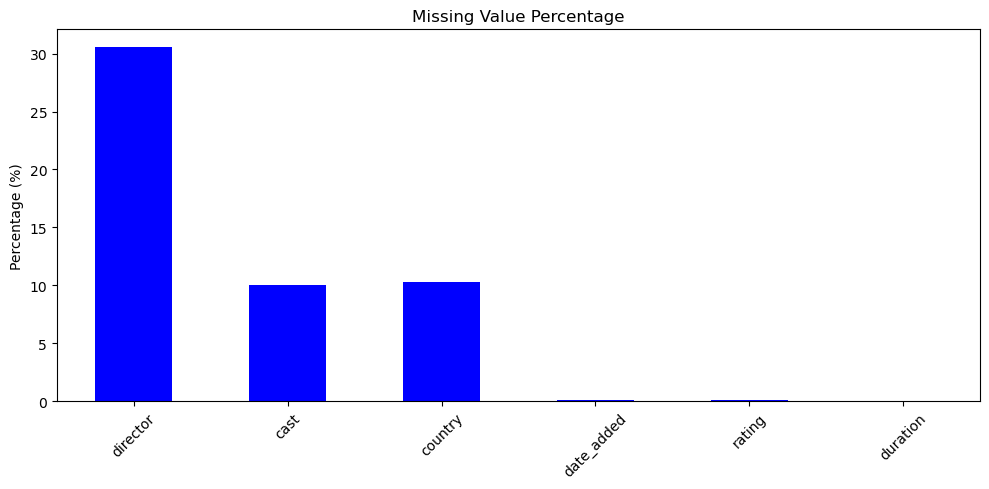

In [10]:
visualization.plot_missing_percentage(df)

## Missing Values Analysis

This step counts missing values in each column to understand data completeness.

In [11]:

df = preprocess.handle_missing_values(df)
df.isnull().sum()

id              0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
platform        0
dtype: int64

## Dropping Unnecessary Columns

Some columns such as 'id' and 'title' do not contribute to predicting the genre.
Removing such columns helps improve model performance and reduces noise.

In [12]:
df = feature_engineering.drop_unnecessary_columns(df)
df.columns

Index(['type', 'title', 'director', 'cast', 'country', 'release_year',
       'rating', 'duration', 'listed_in', 'description', 'platform'],
      dtype='object')

In [13]:
df['listed_in'].value_counts()

listed_in
Documentaries                                         322
Dramas, International Movies                          320
Stand-Up Comedy                                       307
Comedies, Dramas, International Movies                250
Dramas, Independent Movies, International Movies      225
                                                     ... 
Children & Family Movies, Classic Movies, Dramas        1
Horror Movies, Romantic Movies, Sci-Fi & Fantasy        1
Classic & Cult TV, Kids' TV, TV Action & Adventure      1
TV Comedies, TV Dramas, TV Sci-Fi & Fantasy             1
Action-Adventure, Animals & Nature, Animation           1
Name: count, Length: 825, dtype: int64

In [14]:
genre_counts=df['listed_in'].str.split(',').explode().str.strip().value_counts()
print('Total unique genres:',len(genre_counts))
genre_counts.head(10)

Total unique genres: 84


listed_in
International Movies        2476
Dramas                      2183
Comedies                    1500
International TV Shows      1223
Documentaries                790
Action & Adventure           772
Independent Movies           685
TV Dramas                    681
Family                       611
Children & Family Movies     562
Name: count, dtype: int64

In [15]:
df=feature_engineering.consolidate_genres(df)
print(f"Classes after consolidation: {df['listed_in'].nunique()}")
print(df['listed_in'].value_counts())

Classes after consolidation: 9
listed_in
Comedies                    1766
Dramas                      1725
Action & Adventure          1265
Documentaries               1199
International TV Shows       925
Children & Family Movies     915
Animation                    501
Crime & Thriller TV          386
Thrillers                    313
Name: count, dtype: int64


In [16]:
df.shape

(8995, 11)

In [17]:
rows_after = df.shape[0]

rows_dropped = rows_before - rows_after

percent_dropped = (rows_dropped / rows_before) * 100

print("Rows after consolidation:", rows_after)
print("Rows dropped:", rows_dropped)
print("Perceentage dropped: {:.2f}%".format(percent_dropped))

Rows after consolidation: 8995
Rows dropped: 343
Perceentage dropped: 3.67%


In [18]:
df['clean_desc'] = df['description'].apply(feature_engineering.clean_text)

In [19]:
df = feature_engineering.combine_text_features(df)
df[['combined_text']].head()

,combined_text
0,movie tv y united states chuchutv surprise egg...
1,movie r united states journey destination ben ...
2,tv tv ma france returned anne cosigny fr d ric...
3,movie tv y india super bheem bana vajraveer so...
4,movie pg united states germany star trek chris...


In [20]:
df['combined_text'].loc[0]

'movie tv y united states chuchutv surprise eggs learning videos english david attenborough jack hannah colors letters animals kinds egg holds fun filled lesson waiting learned chuchu friends opening colors letters animals kinds egg holds fun filled lesson waiting learned chuchu friends opening'

In [21]:
df.head()

,type,title,director,cast,country,release_year,rating,duration,listed_in,description,platform,clean_desc,combined_text
0,Movie,ChuChuTV Surprise Eggs Learning Videos (English),Jack Hannah,David Attenborough,United States,2019,TV-Y,61 min,Children & Family Movies,From colors and letters to animals of all kind...,Netflix,colors letters animals kinds egg holds fun fil...,movie tv y united states chuchutv surprise egg...
1,Movie,The Journey Is the Destination,Bronwen Hughes,"Ben Schnetzer, Kelly Macdonald, Sam Hazeldine,...",United States,2016,R,123 min,Dramas,Spirited 22-year-old activist and photojournal...,Netflix,spirited year old activist photojournalist dan...,movie r united states journey destination ben ...
2,TV Show,The Returned,Jack Hannah,"Anne Cosigny, Frédéric Pierrot, Clotilde Hesme...",France,2015,TV-MA,1 Season,International TV Shows,On returning home and finding they're believed...,Netflix,returning home finding believed dead collectio...,tv tv ma france returned anne cosigny fr d ric...
3,Movie,Super Bheem Bana Vajraveer,Sumit Das,"Sonal Kaushal, Rupa Bhimani, Julie Tejwani, Sa...",India,2018,TV-Y7,63 min,Children & Family Movies,"Hoping to find a magical root, a monster has c...",Netflix,hoping magical root monster captured farmers l...,movie tv y india super bheem bana vajraveer so...
4,Movie,Star Trek,J.J. Abrams,"Chris Pine, Zachary Quinto, Karl Urban, Zoe Sa...","United States, Germany",2009,PG-13,128 min,Action & Adventure,On their first voyage aboard the starship Ente...,Netflix,voyage aboard starship enterprise cocky rebel ...,movie pg united states germany star trek chris...


## Exploratory Data Visualization

Visualizations help understand the structure and distribution of the dataset.  
This step includes plotting genre distribution, content type distribution, release year trends, and missing value patterns.

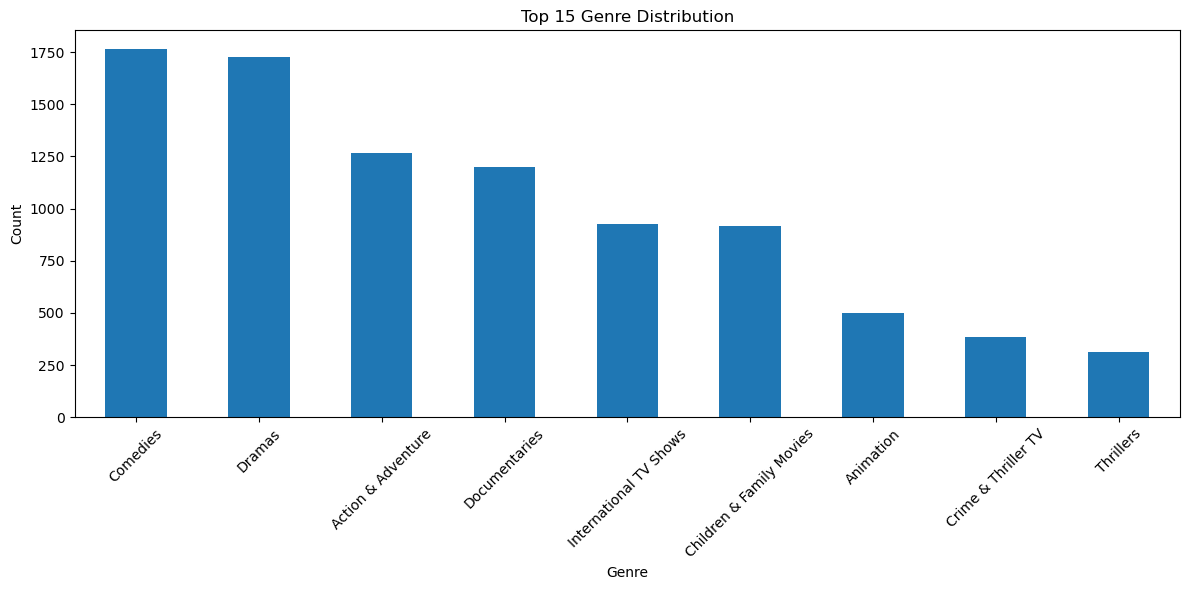

In [22]:
visualization.plot_genre_distribution(df)

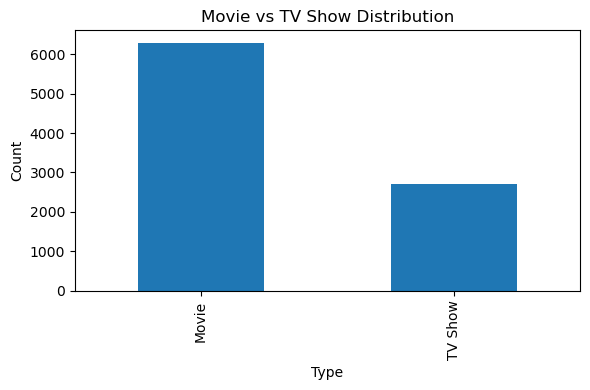

In [23]:
visualization.plot_type_distribution(df)

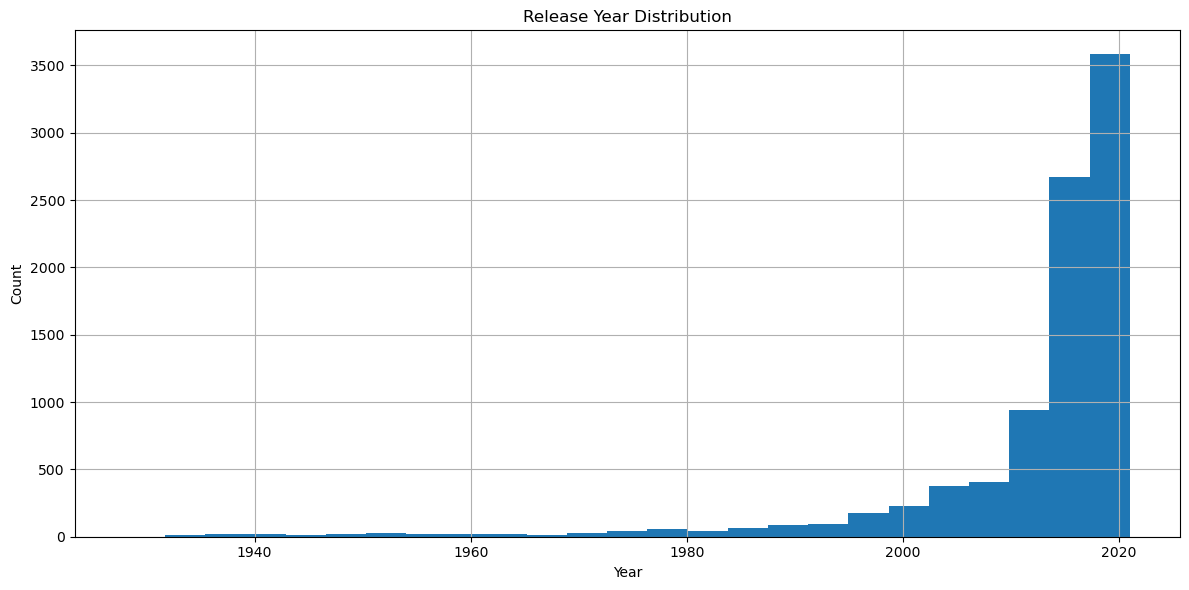

In [24]:
visualization.plot_release_year_distribution(df)

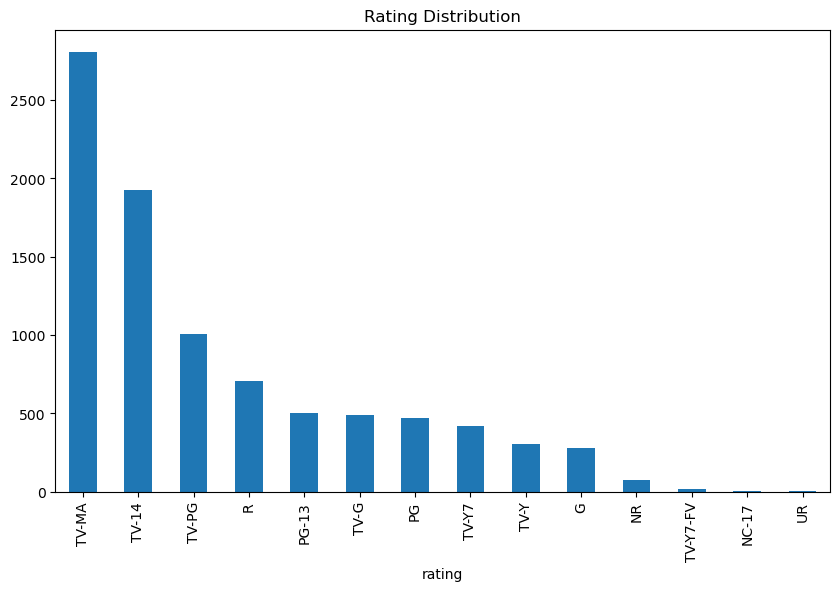

In [25]:
visualization.plot_rating_distribution(df)

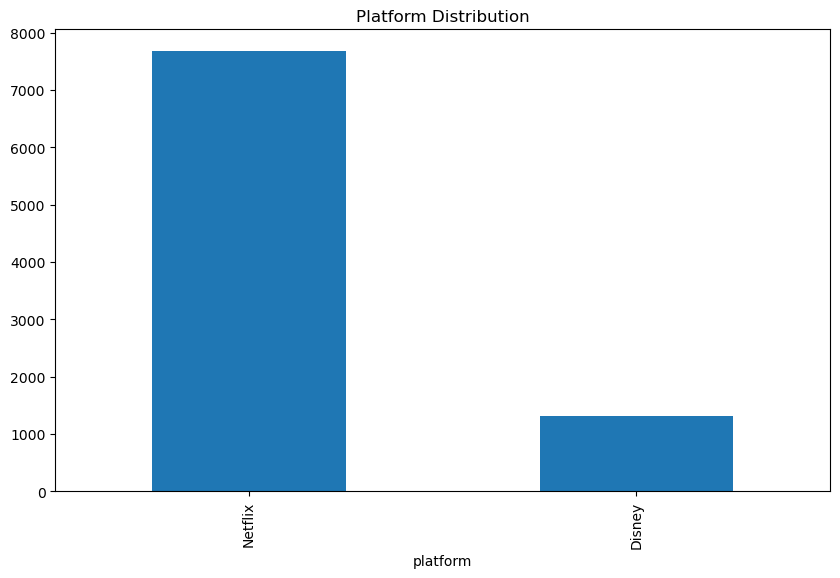

In [26]:
visualization.plot_platform_distribution(df)

## Correlation Analysis

Correlation analysis was not performed because the dataset contains only one primary numerical feature (release_year). Since correlation requires multiple numerical variables, performing correlation analysis would not provide meaningful insights.

## Target Variable Selection

The column 'listed_in' represents the genre of the TV show or movie.
This will be used as the target variable for prediction.

## Splitting Features and Target

The dataset is divided into input features (X) and target variable (y).

In [27]:
X, y = feature_engineering.split_features_target(df)

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (8995, 12)
Target Shape: (8995,)


## Text Vectorization using TF-IDF

Text data is converted into numerical form using TF-IDF vectorization.
This allows machine learning models to process textual information.

In [28]:
x_tfidf, tfidf, ohe = feature_engineering.apply_tfidf(df)
print('Feature matrix shape:', x_tfidf.shape)

Feature matrix shape: (8995, 60018)


## Feature Scaling Decision

Feature scaling was not applied because TF-IDF vectorization inherently normalizes text features.Since the models (Logistic Regression and Linear SVM) are trained on TF-IDF Features, additional scaling was not necessary.

## Train-Test Split

The dataset is divided into training and testing sets.
This helps evaluate model performance on unseen data.

In [29]:
X_train, X_test, y_train, y_test = data_split.split_data(
    x_tfidf,
    y
)
print(X_train.shape)
print(X_test.shape)

(7196, 60018)
(1799, 60018)


## Model Training

Two machine learning models were selected for this task:

1. Logistic Regression — suitable for high-dimensional sparse data
2. Linear SVM — effective for high-dimensional text data and capable of finding optimal decision boundaries for classification.

In [30]:
lr_model = train.train_logistic_regression(X_train,y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


In [31]:
svm_model = train.train_svm(X_train,y_train)

Fitting 5 folds for each of 4 candidates, totalling 20 fits


## Model Evaluation

In this step, both models are evaluated using standard classification metrics such as accuracy, precision, recall, and F1-score.

These metrics help compare model performance and determine the best-performing model.

In [32]:

lr_results = evaluate.evaluate_model(lr_model,X_test,y_test)

print("Logistic Regression Results:")
print("Accuracy:", lr_results["accuracy"])
print("F1 Score:", lr_results["f1_score"])


Logistic Regression Results:
Accuracy: 0.6903835464146748
F1 Score: 0.6883923233196267


In [33]:
svm_results = evaluate.evaluate_model(svm_model,X_test,y_test)

print("Linear SVM Results:")
print("Accuracy:", svm_results["accuracy"])
print("F1 Score:", svm_results["f1_score"])

Linear SVM Results:
Accuracy: 0.7065036131183992
F1 Score: 0.7042829164890545


## Model Comparison

The performance of Logistic Regression and Random Forest models is compared based on evaluation metrics.

In [34]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Linear SVM"],
    "Accuracy": [
        lr_results["accuracy"],
        svm_results["accuracy"]
    ],
    "F1 Score": [
        lr_results["f1_score"],
        svm_results["f1_score"]
    ]
})

comparison

,Model,Accuracy,F1 Score
0,Logistic Regression,0.690384,0.688392
1,Linear SVM,0.706504,0.704283


In [35]:
y_pred_lr = lr_model.predict(X_test)
y_pred_svm = svm_model.predict(X_test)

## Confusion Matrix Visualization

Confusion matrices help visualize how well the model predicts each class.

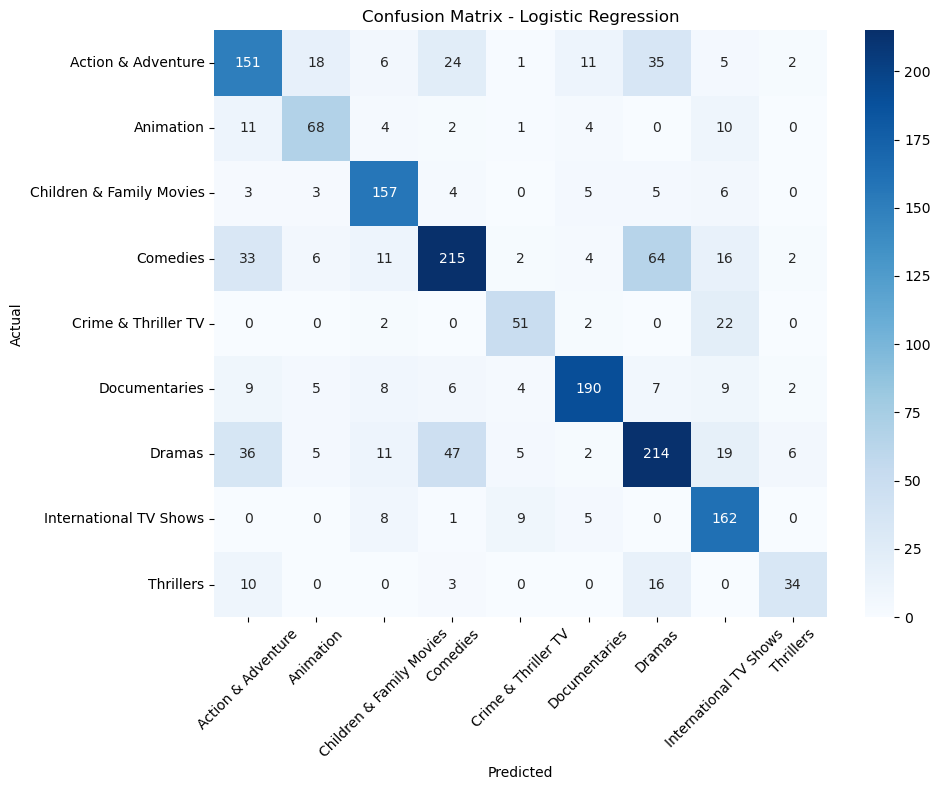

In [36]:
visualization.plot_confusion_matrix(y_test,y_pred_lr,title="Confusion Matrix - Logistic Regression")

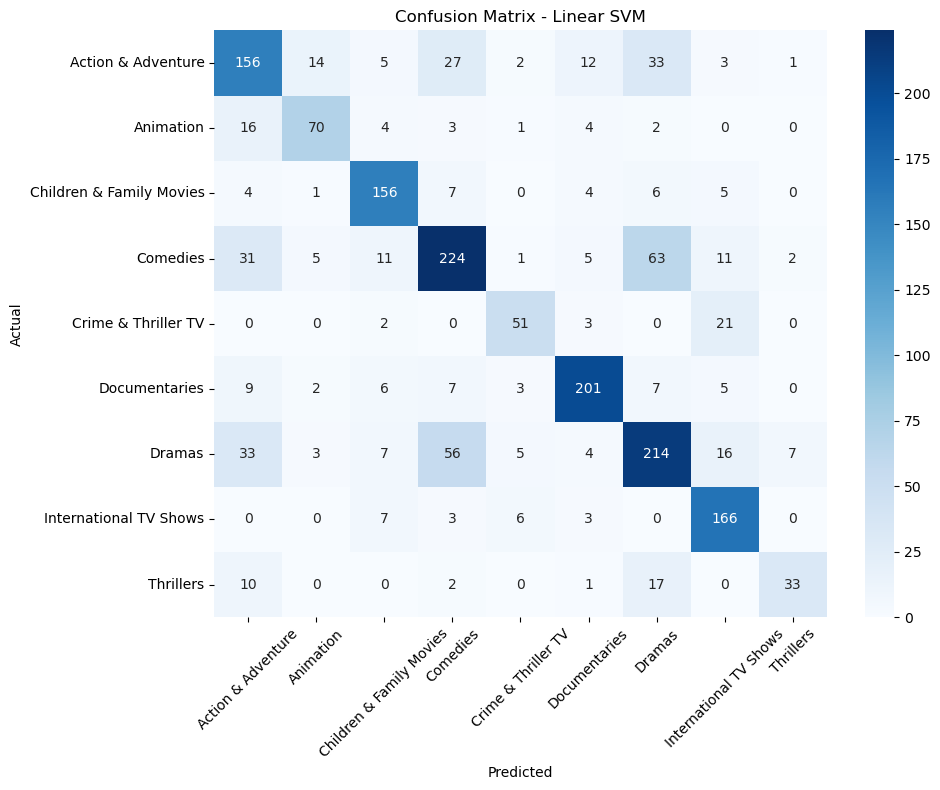

In [37]:
visualization.plot_confusion_matrix(y_test,y_pred_svm,title="Confusion Matrix - Linear SVM")

## Model Explaonability -  Feature Importance

Feature importance was analyzed using Logistic Regression coefficients. The most influential words contributing to genre prediction are visulized below.


Top Important Features:

                Feature    Importance
60017  platform_Netflix  3.439224e-14
60013      rating_TV-Y7  2.917419e-14
26518           kingdom  2.252519e-14
8779              drama  2.111891e-14
8372             disney  1.912513e-14
57600     united states  1.904649e-14
57292          tv japan  1.827550e-14
60001      type_TV Show  1.243450e-14
6153              comic  1.223712e-14
60012       rating_TV-Y  1.129960e-14
54271           stories  1.060880e-14
52769            states  9.794634e-15
39073          pg japan  9.751459e-15
39452            police  9.510911e-15
57599    united kingdom  8.844777e-15


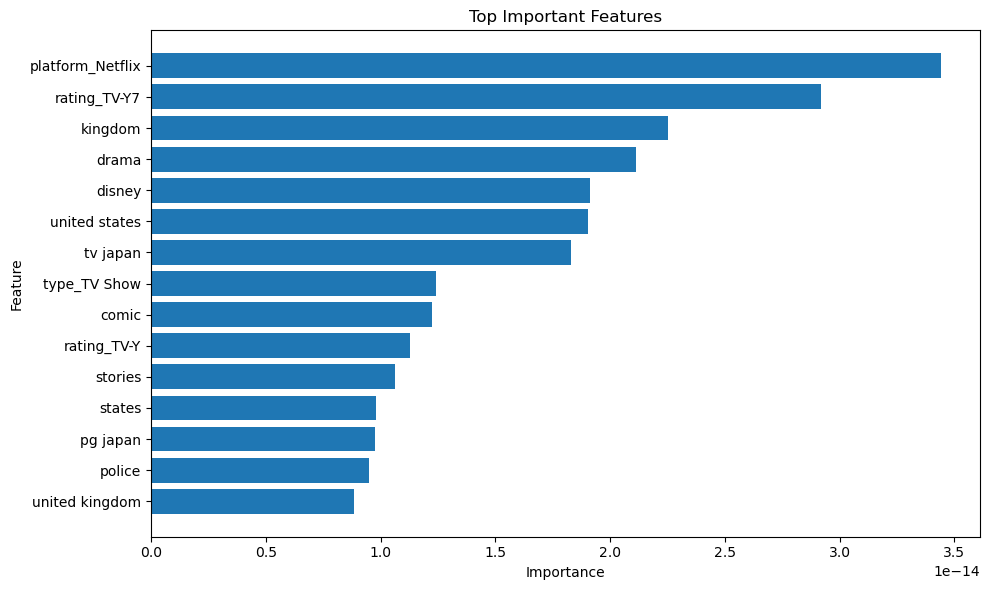

In [45]:
visualization.plot_feature_importance(lr_model,tfidf,ohe,top_n=15)


Top Important Features:

             Feature  Importance
52950  states disney    0.134545
17363           girl    0.125142
49522         shorts    0.121051
36681     mysterious    0.107333
10432         family    0.104099
8372          disney    0.093954
44792         return    0.091084
39073       pg japan    0.089458
36828          nancy    0.089266
24436         jungle    0.082581
49372        sheriff    0.082441
57370        typical    0.081361
10705            fbi    0.080411
3257        big city    0.080195
59966         zombie    0.078787


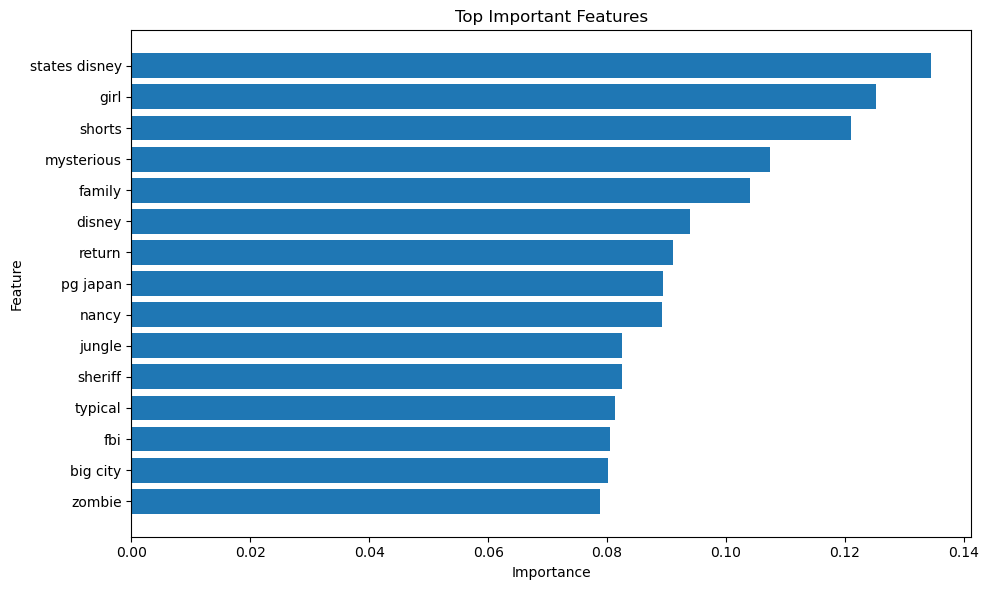

In [46]:
visualization.plot_feature_importance(svm_model,tfidf,ohe,top_n=15)

In [41]:
print("Feature Names Length:", len(tfidf.get_feature_names_out()))

print("Model coef shape:", lr_model.coef_.shape)

importance = np.mean(lr_model.coef_, axis=0)
print("Importance Length:", len(importance))

Feature Names Length: 60000
Model coef shape: (9, 60018)
Importance Length: 60018


In [ ]:
results_lr = pd.DataFrame({"Actual":y_test,"Predicted":y_pred_lr})

results_svm = pd.DataFrame({"Actual":y_test,"Predicted":y_pred_svm})

In [ ]:
right_predictions_lr = results_lr[
    results_lr["Actual"] == results_lr["Predicted"]
]

right_predictions_svm = results_svm[
    results_svm["Actual"] == results_svm["Predicted"]
]

print("Correct Prredictions - Logistic Regression:",len(right_predictions_lr))
print("Correct Prredictions - Linear SVM:",len(right_predictions_svm))


In [ ]:
wrong_predictions_lr = results_lr[
    results_lr["Actual"] != results_lr["Predicted"]
]

wrong_predictions_svm = results_svm[
    results_svm["Actual"] != results_svm["Predicted"]
]

print("Correct Prredictions - Logistic Regression:",len(wrong_predictions_lr))
print("Correct Prredictions - Linear SVM:",len(wrong_predictions_svm))

## Model Recommendation

Two models were evaluated: Logistic Regression and Linear SVM.

Both models performed well on the dataset; however, Linear SVM achieved slightly better performance in terms of Accuracy and F1 Score.

Linear SVM is recommended as the final model because it performs well with high-dimensional sparse data such as TF-IDF features and demonstrated better generalization capability.

Accuracy and F1-score were selected as evaluation metrics because this is a multi-class classification problem.